In [1]:
!pip install kraken==6.0.3 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 48.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.3/114.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.0/811.0 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 65.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 87.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 53.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 MB 2.3 MB/s eta 0:00:00

In [2]:
!ketos compile /kaggle/input/datasets/alwynsajan/trained-models/fraktur_seg.mlmodel/checkpoint_00-0.0292.ckpt -o /kaggle/working/final_model.mlmodel

[04/20/26 02:46:42] WARNING  Invalid input file             ]8;id=207237;file:///usr/local/lib/python3.12/dist-packages/kraken/lib/arrow_dataset.py\arrow_dataset.py]8;;\:]8;id=242129;file:///usr/local/lib/python3.12/dist-packages/kraken/lib/arrow_dataset.py#174\174]8;;\━━━━━━   0% 0/0 -:--:-- -:--:--
                             /kaggle/input/datasets/alwynsa                     
                             jan/trained-models/fraktur_seg                     
                             .mlmodel/checkpoint_00-0.0292.                     
                             ckpt                                               
Extracting lines ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% 0/0 -:--:-- 0:00:0090m━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% 0/0 -:--:-- -:--:--
Output file written to /kaggle/working/final_model.mlmodel


In [3]:
import sys
!pip show kraken

Name: kraken
Version: 6.0.3
Summary: OCR/HTR engine for all the languages
Home-page: https://kraken.re
Author: Benjamin Kiessling
Author-email: mittagessen@l.unchti.me
License: Apache
Location: /usr/local/lib/python3.12/dist-packages
Requires: click, coremltools, htrmopo, iso639-lang, jinja2, jsonschema, lightning, lxml, numpy, Pillow, platformdirs, protobuf, pyarrow, python-bidi, regex, requests, rich, scikit-image, scikit-learn, scipy, shapely, threadpoolctl, torch, torchmetrics, torchvision
Required-by: 


In [4]:
import sys
import types
import torch

# Create fake kraken.configs modules
mock_configs = types.ModuleType('kraken.configs')
mock_vgsl = types.ModuleType('kraken.configs.vgsl')

# Dummy base class that accepts anything
class _AnyConfig:
    def __init__(self, *args, **kwargs):
        self.__dict__.update(kwargs)
    def __setstate__(self, state):
        self.__dict__.update(state)

# Register all config classes kraken may have saved
mock_vgsl.BLLASegmentationTrainingConfig = type('BLLASegmentationTrainingConfig', (_AnyConfig,), {})
mock_vgsl.BLLASegmentationTrainingDataConfig = type('BLLASegmentationTrainingDataConfig', (_AnyConfig,), {})

mock_configs.vgsl = mock_vgsl

sys.modules['kraken.configs'] = mock_configs
sys.modules['kraken.configs.vgsl'] = mock_vgsl

# Now load
ckpt_path = "/kaggle/input/datasets/alwynsajan/trained-models/fraktur_seg.mlmodel/checkpoint_04-0.0919.ckpt"
ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)

print("Top-level keys:", list(ckpt.keys()))
if 'hyper_parameters' in ckpt:
    print("\nHyper params:", ckpt['hyper_parameters'])
if 'state_dict' in ckpt:
    sd_keys = list(ckpt['state_dict'].keys())
    print("\nState dict keys (first 10):", sd_keys[:10])

Top-level keys: ['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers', 'hparams_name', 'hyper_parameters', 'datamodule_hparams_name', 'datamodule_hyper_parameters', '_module_config', '_one_channel_mode', '_canonical_class_mapping']

Hyper params: {'config': <__main__.BLLASegmentationTrainingConfig object at 0x7fd5e2007a70>}

State dict keys (first 10): ['net.nn.C_0.co.weight', 'net.nn.C_0.co.bias', 'net.nn.Gn_1.layer.weight', 'net.nn.Gn_1.layer.bias', 'net.nn.C_2.co.weight', 'net.nn.C_2.co.bias', 'net.nn.Gn_3.layer.weight', 'net.nn.Gn_3.layer.bias', 'net.nn.C_4.co.weight', 'net.nn.C_4.co.bias']


In [5]:
import sys
import types
import torch
from kraken.lib.vgsl import TorchVGSLModel
from kraken import blla
from PIL import Image
import matplotlib.pyplot as plt

# Mock missing modules
mock_configs = types.ModuleType('kraken.configs')
mock_vgsl = types.ModuleType('kraken.configs.vgsl')

class _AnyConfig:
    def __init__(self, *args, **kwargs):
        self.__dict__.update(kwargs)
    def __setstate__(self, state):
        self.__dict__.update(state)

mock_vgsl.BLLASegmentationTrainingConfig = type('BLLASegmentationTrainingConfig', (_AnyConfig,), {})
mock_vgsl.BLLASegmentationTrainingDataConfig = type('BLLASegmentationTrainingDataConfig', (_AnyConfig,), {})
mock_configs.vgsl = mock_vgsl
sys.modules['kraken.configs'] = mock_configs
sys.modules['kraken.configs.vgsl'] = mock_vgsl

# Load checkpoint
ckpt_path = "/kaggle/input/datasets/alwynsajan/trained-models/fraktur_seg.mlmodel/checkpoint_04-0.0919.ckpt"
ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)

# Inspect _module_config — this has the VGSL spec we need
print("_module_config:", ckpt['_module_config'])
print("_one_channel_mode:", ckpt['_one_channel_mode'])
print("_canonical_class_mapping:", ckpt['_canonical_class_mapping'])

2026-04-20 02:47:00.980092: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776653221.170281      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776653221.227984      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776653221.694629      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776653221.694662      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776653221.694665      55 computation_placer.cc:177] computation placer alr

_module_config: <__main__.BLLASegmentationTrainingConfig object at 0x7fd5141692e0>
_one_channel_mode: RGB
_canonical_class_mapping: {'aux': {'_start_separator': 0, '_end_separator': 1}, 'baselines': {'corrected': 2, 'default': 15, 'caption': 19, 'separator_short': 21, 'uncertain': 22, 'paragraph': 23, 'separator_vertical': 25, 'header': 26}, 'regions': {'separator_vertical': 3, 'separator_short': 4, 'separator_horizontal': 5, 'caption': 6, 'heading': 7, 'paragraph': 8, 'header': 9, 'table': 10, 'Image': 11, 'separator': 12, 'uncertain': 13, 'inverted_text': 14, 'graphic': 16, 'image': 17, 'text': 18, 'corrected': 20, 'UnkownRegion': 24}}


In [6]:
config = ckpt['_module_config']
print(config.__dict__)

{'spec': '[1,1800,0,3 Cr7,7,64,2,2 Gn32 Cr3,3,128,2,2 Gn32 Cr3,3,128 Gn32 Cr3,3,256 Gn32 Cr3,3,256 Gn32 Lbx32 Lby32 Cr1,1,32 Gn32 Lby32 Lbx32 O2l27]', 'padding': (0, 0), 'resize': 'fail', 'bl_tol': 10.0, 'dice_weight': 0.5, 'epochs': 5, 'completed_epochs': 0, 'freq': 1.0, 'checkpoint_path': 'model', 'weights_format': 'safetensors', 'optimizer': 'AdamW', 'lrate': 0.0002, 'momentum': 0.9, 'weight_decay': 1e-05, 'gradient_clip_val': 1.0, 'accumulate_grad_batches': 1, 'schedule': 'constant', 'warmup': 0, 'step_size': 10.0, 'gamma': 0.1, 'rop_factor': 0.1, 'rop_patience': 5, 'cos_t_max': 50, 'cos_min_lr': 2e-05, 'quit': 'fixed', 'min_epochs': 0, 'lag': 10, 'min_delta': 0.0, 'precision': '32-true', 'accelerator': 'auto', 'device': 'auto', 'batch_size': 1, 'compile_config': None, 'raise_on_error': False, 'num_threads': 1}


Model loaded!
Lines found: 42
Regions found: 17


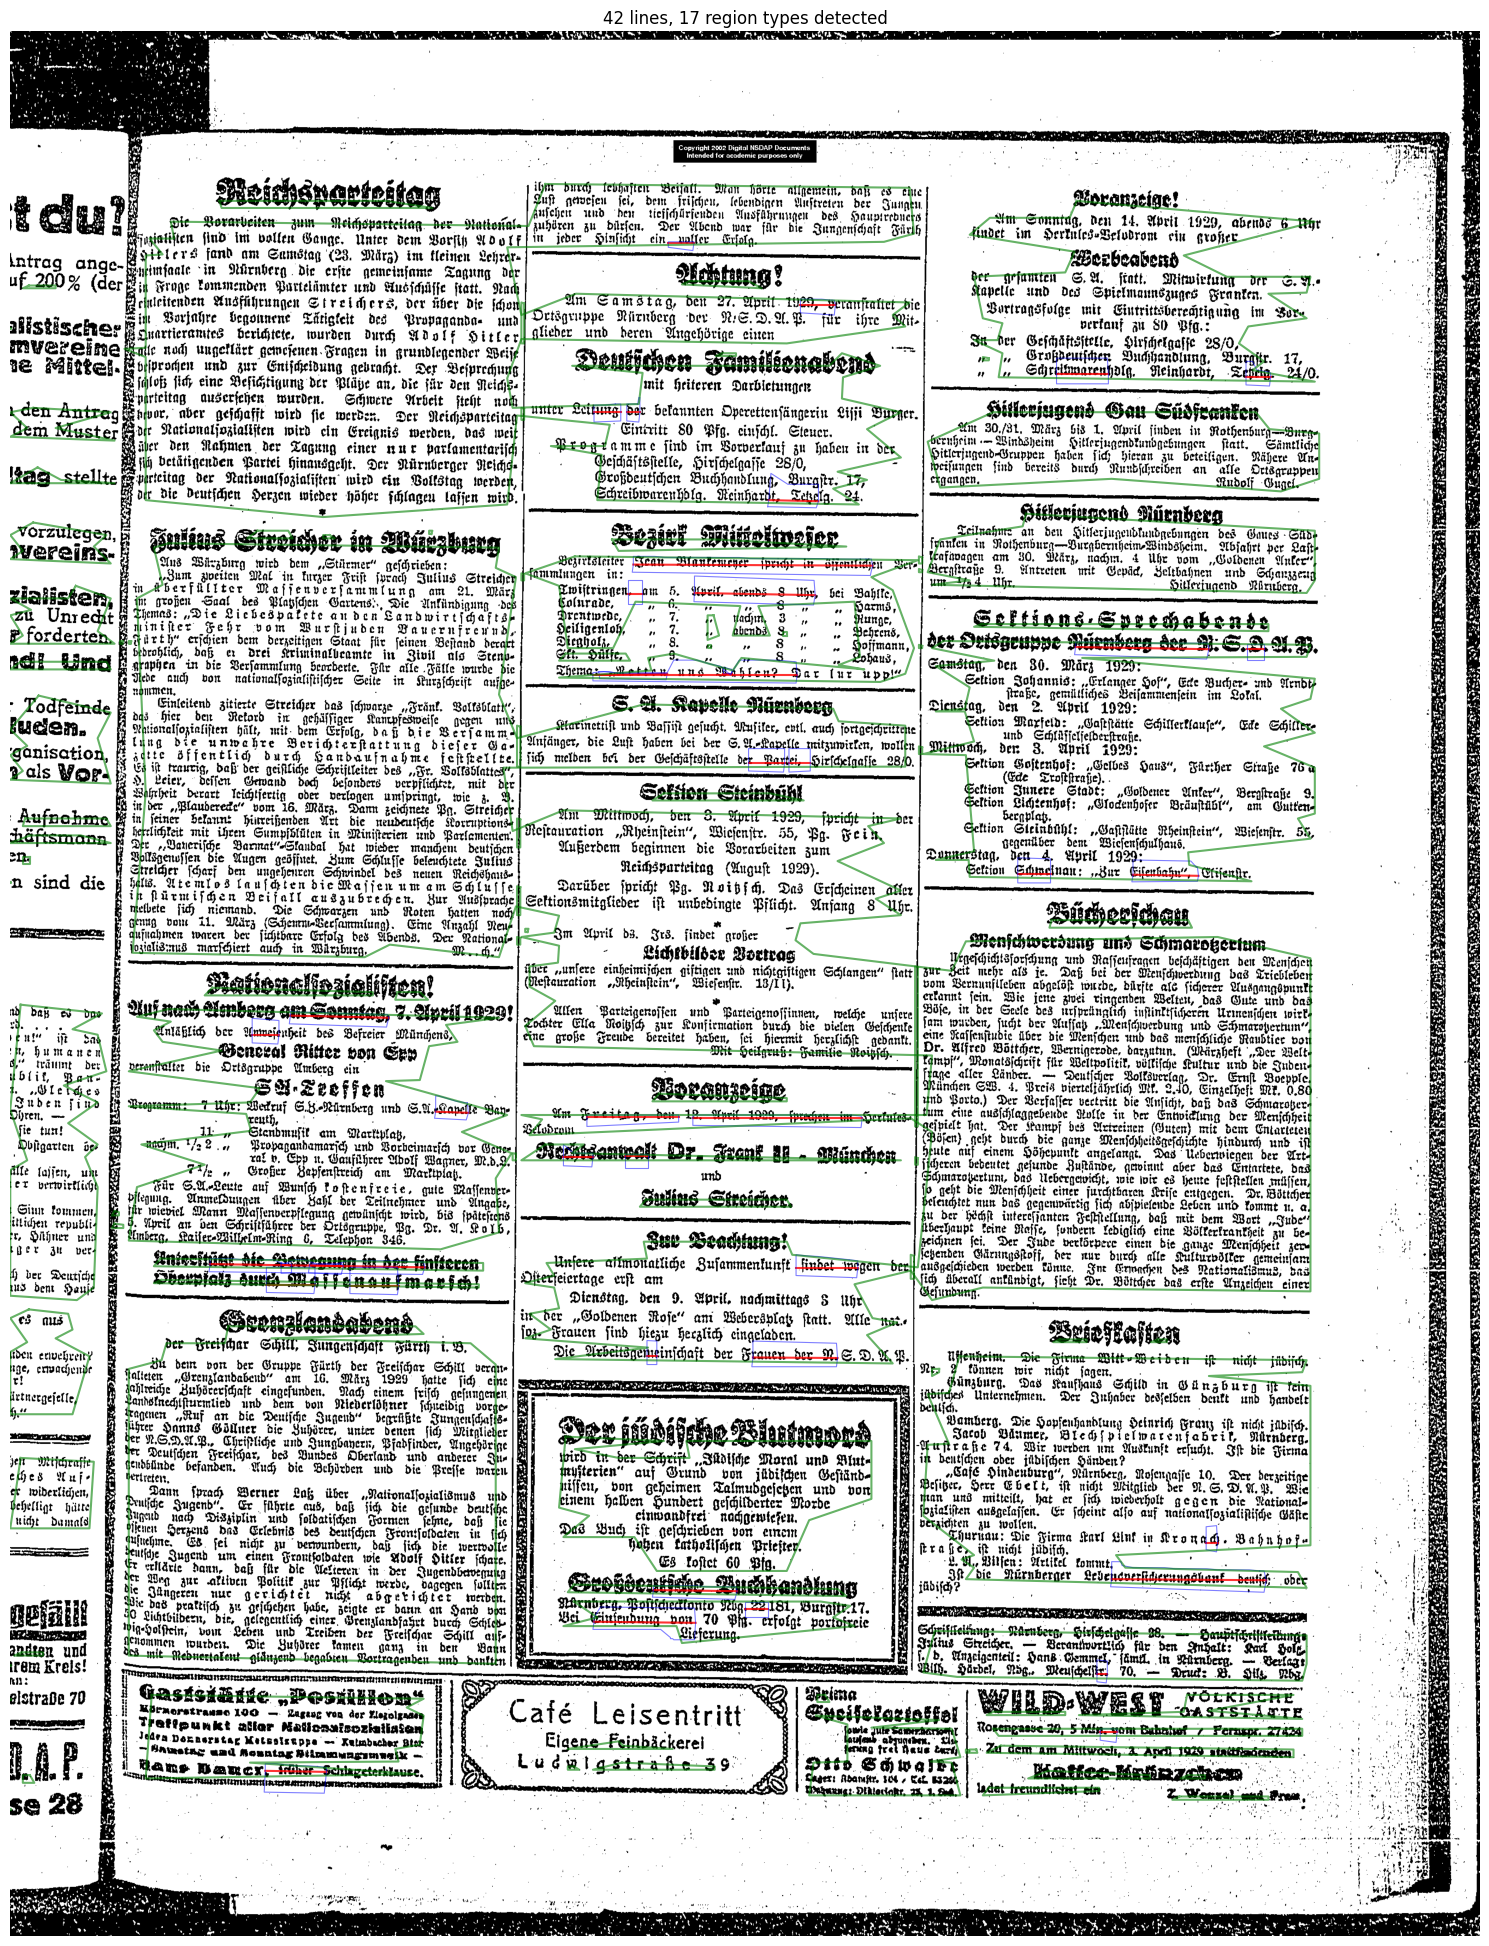

In [7]:
import sys
import types
import torch
from kraken.lib.vgsl import TorchVGSLModel
from kraken import blla
from PIL import Image
import matplotlib.pyplot as plt

mock_configs = types.ModuleType('kraken.configs')
mock_vgsl = types.ModuleType('kraken.configs.vgsl')

class _AnyConfig:
    def __init__(self, *args, **kwargs):
        self.__dict__.update(kwargs)
    def __setstate__(self, state):
        self.__dict__.update(state)

mock_vgsl.BLLASegmentationTrainingConfig = type('BLLASegmentationTrainingConfig', (_AnyConfig,), {})
mock_vgsl.BLLASegmentationTrainingDataConfig = type('BLLASegmentationTrainingDataConfig', (_AnyConfig,), {})
mock_configs.vgsl = mock_vgsl
sys.modules['kraken.configs'] = mock_configs
sys.modules['kraken.configs.vgsl'] = mock_vgsl

ckpt_path = "/kaggle/input/datasets/alwynsajan/trained-models/fraktur_seg.mlmodel/checkpoint_04-0.0919.ckpt"
ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)

vgsl_spec = '[1,1800,0,3 Cr7,7,64,2,2 Gn32 Cr3,3,128,2,2 Gn32 Cr3,3,128 Gn32 Cr3,3,256 Gn32 Cr3,3,256 Gn32 Lbx32 Lby32 Cr1,1,32 Gn32 Lby32 Lbx32 O2l27]'
seg_model = TorchVGSLModel(vgsl_spec)

stripped = {k.replace('net.nn.', '', 1): v 
            for k, v in ckpt['state_dict'].items() 
            if k.startswith('net.nn.')}
seg_model.nn.load_state_dict(stripped)
seg_model.eval()

# All metadata must go inside user_metadata dict since they are all properties
seg_model.user_metadata = {
    'model_type': 'segmentation',
    'one_channel_mode': 'RGB',
    'class_mapping': ckpt['_canonical_class_mapping'],
    'topline': False,
    'hyper_params': {
        'padding': (0, 0),
        'resize': 'fail',
    },
}

print("Model loaded!")

im = Image.open("/kaggle/input/datasets/alwynsajan/kraken-data/0430.tif").convert('RGB')

import traceback
try:
    result = blla.segment(im, model=seg_model)
    print(f"Lines found: {len(result.lines)}")
    print(f"Regions found: {len(result.regions)}")

    fig, ax = plt.subplots(figsize=(15, 20))
    ax.imshow(im)
    for line in result.lines:
        if line.baseline:
            xs = [p[0] for p in line.baseline]
            ys = [p[1] for p in line.baseline]
            ax.plot(xs, ys, 'r-', linewidth=1.5, alpha=0.8)
        if line.boundary:
            xs = [p[0] for p in line.boundary] + [line.boundary[0][0]]
            ys = [p[1] for p in line.boundary] + [line.boundary[0][1]]
            ax.plot(xs, ys, 'b-', linewidth=0.8, alpha=0.5)
    for region_type, region_list in result.regions.items():
        for region in region_list:
            if region.boundary:
                xs = [p[0] for p in region.boundary] + [region.boundary[0][0]]
                ys = [p[1] for p in region.boundary] + [region.boundary[0][1]]
                ax.plot(xs, ys, 'g-', linewidth=1.5, alpha=0.6)
    ax.set_title(f"{len(result.lines)} lines, {len(result.regions)} region types detected")
    ax.axis('off')
    plt.tight_layout()
    plt.savefig("segmentation_result.png", dpi=150, bbox_inches='tight')
    plt.show()

except Exception as e:
    traceback.print_exc()

In [8]:
# Download the segmentation result
from IPython.display import FileLink, display
display(FileLink('segmentation_result.png'))

/kaggle/working/segmentation_result.png